# Unsupervised Learning: GMM, PCA, K-Means, and a Minimal GAN (From Scratch + Libraries)

This Colab notebook contains **beginner-friendly, line-by-line commented** examples for:

1. **Gaussian Mixture Model (GMM)** — from scratch via EM + scikit-learn
2. **Principal Component Analysis (PCA)** — from scratch + scikit-learn
3. **K-Means Clustering** — from scratch + scikit-learn
4. **Generative Adversarial Network (GAN)** — a minimal 1D GAN with a **stable GradientTape** training loop

**Plotting policy**: we use **matplotlib** only, **one chart per figure**, and **no explicit colors**.


In [ ]:
!pip install -q scikit-learn matplotlib numpy tensorflow

import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True

try:
    from sklearn.mixture import GaussianMixture
    from sklearn.decomposition import PCA as SKPCA
    from sklearn.cluster import KMeans as SKKMeans
    SKLEARN_AVAILABLE = True
except Exception as e:
    SKLEARN_AVAILABLE = False
    print("scikit-learn not available:", e)

try:
    import tensorflow as tf
    from tensorflow.keras import layers
    TF_AVAILABLE = True
except Exception as e:
    TF_AVAILABLE = False
    print("TensorFlow not available:", e)

print("Environment ready. SKLEARN_AVAILABLE =", SKLEARN_AVAILABLE, ", TF_AVAILABLE =", TF_AVAILABLE)


Environment ready. SKLEARN_AVAILABLE = True , TF_AVAILABLE = True


## Gaussian Mixture Model (GMM): Math

We assume data $x_i \in \mathbb{R}^d$ are drawn from a mixture of $K$ Gaussians:
$$
p(x) = \sum_{k=1}^K \pi_k \, \mathcal{N}(x \mid \mu_k, \Sigma_k), \quad \sum_k \pi_k = 1,\ \pi_k \ge 0.
$$

**EM algorithm:**

- **E-step (responsibilities)**: for each point $x_i$ and component $k$,
$$
\gamma_{ik} = \frac{\pi_k \, \mathcal{N}(x_i \mid \mu_k, \Sigma_k)}{\sum_{j=1}^K \pi_j \, \mathcal{N}(x_i \mid \mu_j, \Sigma_j)}.
$$

- **M-step (parameter updates):**
$$
N_k = \sum_{i=1}^n \gamma_{ik}, \quad
\pi_k = \frac{N_k}{n}, \quad
\mu_k = \frac{1}{N_k}\sum_{i=1}^n \gamma_{ik} x_i, \quad
\Sigma_k = \frac{1}{N_k} \sum_{i=1}^n \gamma_{ik} (x_i - \mu_k)(x_i - \mu_k)^\top.
$$

Iterate E/M until convergence (e.g., log-likelihood stabilization).


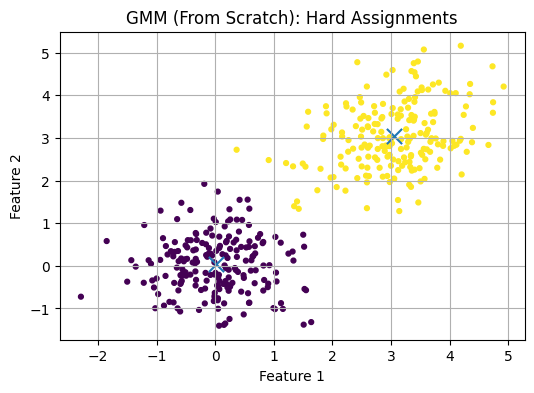

In [ ]:
# === GMM (From Scratch) with EM; with line-by-line comments ===
np.random.seed(42)

# 1) Synthetic data: two 2D Gaussian blobs
num_points_per_blob = 200
mean_blob_1 = np.array([0.0, 0.0])
cov_blob_1  = np.array([[0.5, 0.0],[0.0, 0.5]])
mean_blob_2 = np.array([3.0, 3.0])
cov_blob_2  = np.array([[0.6, 0.2],[0.2, 0.6]])

blob1 = np.random.multivariate_normal(mean_blob_1, cov_blob_1, num_points_per_blob)
blob2 = np.random.multivariate_normal(mean_blob_2, cov_blob_2, num_points_per_blob)
X_gmm = np.vstack([blob1, blob2])

# 2) Multivariate normal pdf helper
def multivariate_normal_pdf(x_matrix, mean_vector, covariance_matrix):
    d = x_matrix.shape[1]
    centered = x_matrix - mean_vector
    inv_cov = np.linalg.inv(covariance_matrix)
    det_cov = np.linalg.det(covariance_matrix)
    exponent = -0.5 * np.sum(centered @ inv_cov * centered, axis=1)
    normalizer = np.sqrt(((2 * np.pi) ** d) * det_cov)
    return np.exp(exponent) / normalizer

# 3) EM implementation
def gmm_em_from_scratch(x_matrix, num_components=2, num_iterations=60, seed=0):
    rng = np.random.default_rng(seed)
    n, d = x_matrix.shape
    means = x_matrix[rng.choice(n, size=num_components, replace=False)]
    covariances = np.array([np.eye(d) for _ in range(num_components)])
    weights = np.ones(num_components) / num_components
    responsibilities = np.zeros((n, num_components))

    for _ in range(num_iterations):
        # E-step: unnormalized responsibilities
        for k in range(num_components):
            responsibilities[:, k] = weights[k] * multivariate_normal_pdf(
                x_matrix, means[k], covariances[k]
            )
        # Normalize to sum to 1 across components
        row_sums = responsibilities.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1.0
        responsibilities /= row_sums

        # M-step: update weights, means, covariances
        Nk = responsibilities.sum(axis=0)
        weights = Nk / n
        for k in range(num_components):
            means[k] = (responsibilities[:, k, None] * x_matrix).sum(axis=0) / max(Nk[k], 1e-12)
            centered = x_matrix - means[k]
            covariances[k] = (
                responsibilities[:, k, None, None]
                * np.einsum("ni,nj->nij", centered, centered)
            ).sum(axis=0) / max(Nk[k], 1e-12)
            covariances[k] += 1e-6 * np.eye(d)
    return weights, means, covariances

weights, means, covariances = gmm_em_from_scratch(X_gmm, num_components=2, num_iterations=60, seed=123)

unnorm = np.stack([weights[k]*multivariate_normal_pdf(X_gmm, means[k], covariances[k]) for k in range(2)], axis=1)
post = unnorm / unnorm.sum(axis=1, keepdims=True)
hard_labels = np.argmax(post, axis=1)

plt.figure()
plt.scatter(X_gmm[:, 0], X_gmm[:, 1], c=hard_labels, s=12)
plt.scatter(means[:, 0], means[:, 1], marker='x', s=120)
plt.title("GMM (From Scratch): Hard Assignments")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


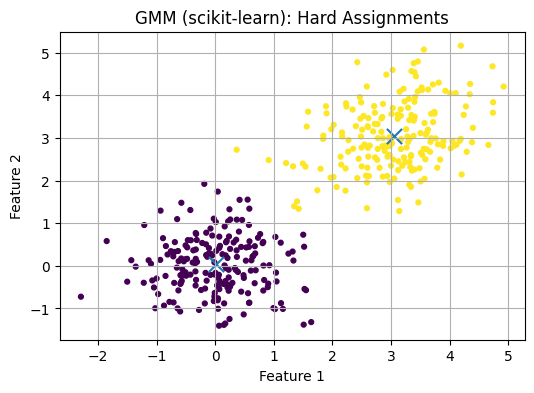

In [ ]:
# === GMM (scikit-learn) ===
if SKLEARN_AVAILABLE:
    gmm = GaussianMixture(n_components=2, random_state=42).fit(X_gmm)
    skl_labels = gmm.predict(X_gmm)
    skl_means = gmm.means_

    plt.figure()
    plt.scatter(X_gmm[:, 0], X_gmm[:, 1], c=skl_labels, s=12)
    plt.scatter(skl_means[:, 0], skl_means[:, 1], marker='x', s=120)
    plt.title("GMM (scikit-learn): Hard Assignments")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()
else:
    print("scikit-learn not available; skipping GMM (scikit-learn).")


## Principal Component Analysis (PCA): Math

Centered data $X$ yields covariance $ \Sigma = \frac{1}{n-1}X^\top X $.
Eigendecompose $ \Sigma = V\Lambda V^\top $, project $ X_{\text{proj}} = X V_{[:,1:m]} $,
and examine explained variance ratios $ \lambda_j / \sum_i \lambda_i $.


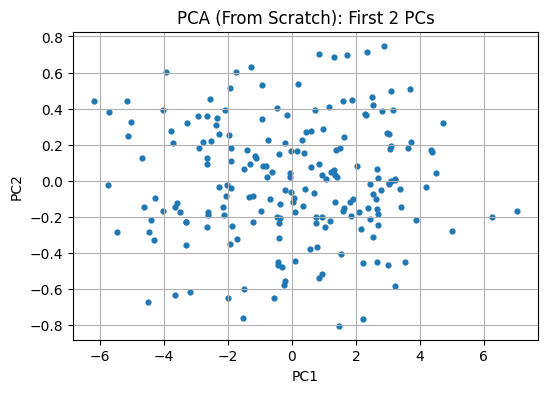

In [ ]:
# === PCA (From Scratch) ===
np.random.seed(0)

# 1) Build a 3D synthetic dataset with correlated features
n_samples = 200
f1 = np.random.normal(0, 1, n_samples)
f2 = 2 * f1 + np.random.normal(0, 0.5, n_samples)
f3 = f1 - f2 + np.random.normal(0, 0.2, n_samples)
X_pca = np.column_stack([f1, f2, f3])

# 2) Center the data
X_centered = X_pca - X_pca.mean(axis=0)

# 3) Covariance and eigendecomposition
Cov = np.cov(X_centered, rowvar=False)
eigenvalues, eigenvectors = np.linalg.eigh(Cov)
order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

# 4) Project onto the first 2 PCs
X_proj = X_centered @ eigenvectors[:, :2]

# 5) Plot
plt.figure()
plt.scatter(X_proj[:, 0], X_proj[:, 1], s=12)
plt.title("PCA (From Scratch): First 2 PCs")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


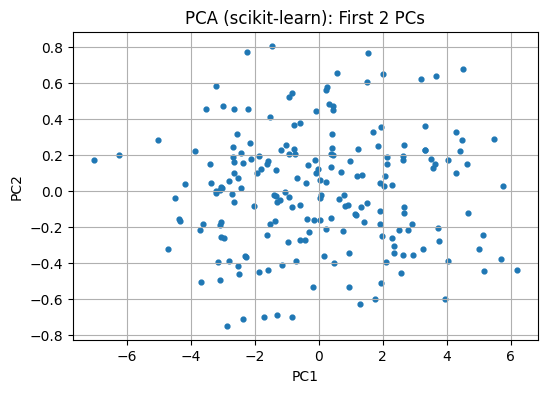

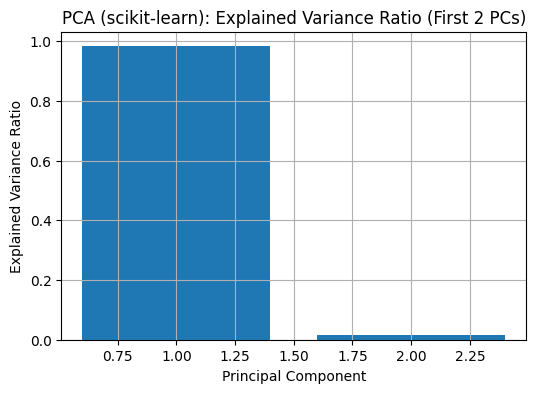

In [ ]:
# === PCA (scikit-learn) ===
if SKLEARN_AVAILABLE:
    pca = SKPCA(n_components=2)
    X_proj_skl = pca.fit_transform(X_pca)
    evr = pca.explained_variance_ratio_

    plt.figure()
    plt.scatter(X_proj_skl[:, 0], X_proj_skl[:, 1], s=12)
    plt.title("PCA (scikit-learn): First 2 PCs")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()

    plt.figure()
    plt.bar([1, 2], evr[:2])
    plt.title("PCA (scikit-learn): Explained Variance Ratio (First 2 PCs)")
    plt.xlabel("Principal Component")
    plt.ylabel("Explained Variance Ratio")
    plt.show()
else:
    print("scikit-learn not available; skipping PCA (scikit-learn).")


## K-Means: Math

Objective: minimize within-cluster sum of squares
$$
\min_{\{C_k\}, \{\mu_k\}} \sum_{k=1}^K \sum_{x_i \in C_k} \|x_i - \mu_k\|^2.
$$
Alternating updates: assign to nearest centroid, then recompute centroids as cluster means.


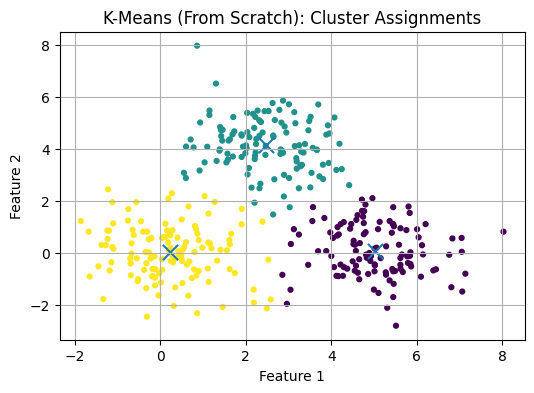

In [ ]:
# === K-Means (From Scratch) ===
np.random.seed(1)

# 1) Generate a 2D dataset with 3 clusters
true_centers = np.array([[0, 0], [5, 0], [2.5, 4]])
points_per_cluster = 120
A = np.random.randn(points_per_cluster, 2) + true_centers[0]
B = np.random.randn(points_per_cluster, 2) + true_centers[1]
C = np.random.randn(points_per_cluster, 2) + true_centers[2]
X_km = np.vstack([A, B, C])

# 2) K-means via Lloyd's algorithm
def kmeans_from_scratch(X, K=3, max_iters=100, seed=0):
    # Randomly pick K points as initial centroids
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    centers = X[rng.choice(n, size=K, replace=False)]

    for _ in range(max_iters):
        # Compute squared distances to each center -> (n, K)
        sq_dists = ((X[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)

        # Assign to nearest center
        labels = np.argmin(sq_dists, axis=1)

        # Update centers as mean of assigned points (if cluster empty, keep old center)
        new_centers = np.array([
            X[labels == k].mean(axis=0) if np.any(labels == k) else centers[k]
            for k in range(K)
        ])

        # If centers did not move much, stop
        if np.allclose(centers, new_centers):
            centers = new_centers
            break

        centers = new_centers

    return centers, labels

centers, labels = kmeans_from_scratch(X_km, K=3, max_iters=100, seed=123)

plt.figure()
plt.scatter(X_km[:, 0], X_km[:, 1], c=labels, s=12)
plt.scatter(centers[:, 0], centers[:, 1], marker='x', s=120)
plt.title("K-Means (From Scratch): Cluster Assignments")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


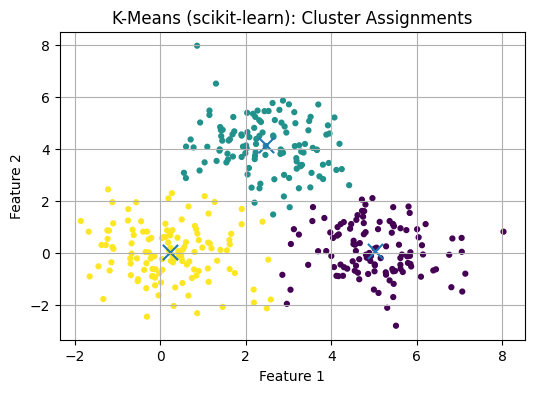

In [ ]:
# === K-Means (scikit-learn) ===
if SKLEARN_AVAILABLE:
    km = SKKMeans(n_clusters=3, n_init=10, random_state=42).fit(X_km)
    labs = km.labels_
    centers_skl = km.cluster_centers_

    plt.figure()
    plt.scatter(X_km[:, 0], X_km[:, 1], c=labs, s=12)
    plt.scatter(centers_skl[:, 0], centers_skl[:, 1], marker='x', s=120)
    plt.title("K-Means (scikit-learn): Cluster Assignments")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()
else:
    print("scikit-learn not available; skipping K-Means (scikit-learn).")


## Minimal 1‑D GAN with GradientTape (Stable Training)

We implement a small GAN that learns $ \mathcal{N}(0,1) $. We train with a **custom loop** to
avoid pitfalls with trainable flags. The discriminator uses standard binary cross-entropy on real
and fake batches; the generator uses the **non‑saturating** loss pushing $ D(G(z)) $ toward 1.


Step 0000 | D loss: 1.3621 | G loss: 0.6937
Step 0100 | D loss: 1.6793 | G loss: 0.4389
Step 0200 | D loss: 1.1448 | G loss: 0.9368
Step 0300 | D loss: 1.6399 | G loss: 0.7305
Step 0400 | D loss: 1.3819 | G loss: 0.7973
Step 0500 | D loss: 1.3781 | G loss: 0.6700
Step 0600 | D loss: 1.4041 | G loss: 0.6711
Step 0700 | D loss: 1.3930 | G loss: 0.7188
Step 0800 | D loss: 1.3833 | G loss: 0.6419
Step 0900 | D loss: 1.3957 | G loss: 0.6392


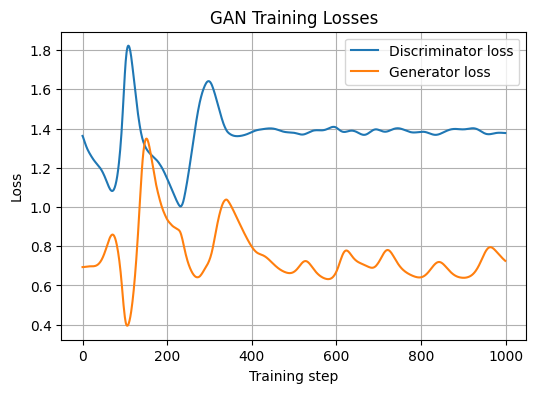

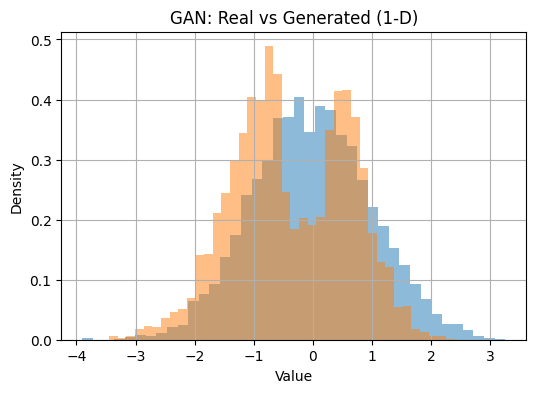

In [ ]:
# === Minimal 1-D GAN with stable GradientTape loop ===
if not TF_AVAILABLE:
    print("TensorFlow not available; install it first (and enable GPU in Colab if desired).")
else:
    # 1) Data & hyperparameters
    rng = np.random.default_rng(0)
    num_real = 4000
    real_data = rng.normal(0.0, 1.0, size=(num_real, 1)).astype("float32")
    batch_size = 128
    epochs = 1000
    noise_dim = 1
    lr = 1e-3

    # 2) Generator: z -> x_fake
    generator = tf.keras.Sequential([
        layers.Input(shape=(noise_dim,)),
        layers.Dense(32, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1)
    ], name="Generator")

    # 3) Discriminator: x -> prob_real
    discriminator = tf.keras.Sequential([
        layers.Input(shape=(1,)),
        layers.Dense(32, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ], name="Discriminator")

    # 4) Optimizers and loss
    d_optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    g_optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    bce = tf.keras.losses.BinaryCrossentropy(from_logits=False)

    # 5) Batch samplers
    def sample_real_batch():
        idx = rng.integers(0, num_real, size=batch_size)
        return real_data[idx]

    def sample_noise_batch():
        return rng.standard_normal(size=(batch_size, noise_dim)).astype("float32")

    # 6) Train discriminator on real and fake
    @tf.function
    def train_discriminator_step():
        x_real = sample_real_batch()
        y_real = tf.ones((batch_size, 1), dtype=tf.float32)
        z = sample_noise_batch()
        x_fake = generator(z, training=True)
        y_fake = tf.zeros((batch_size, 1), dtype=tf.float32)
        with tf.GradientTape() as tape:
            p_real = discriminator(x_real, training=True)
            p_fake = discriminator(x_fake, training=True)
            d_loss = bce(y_real, p_real) + bce(y_fake, p_fake)
        grads = tape.gradient(d_loss, discriminator.trainable_variables)
        d_optimizer.apply_gradients(zip(grads, discriminator.trainable_variables))
        return d_loss

    # 7) Train generator to fool discriminator (non-saturating loss)
    @tf.function
    def train_generator_step():
        z = sample_noise_batch()
        with tf.GradientTape() as tape:
            x_fake = generator(z, training=True)
            p_fake = discriminator(x_fake, training=True)
            y_target = tf.ones((batch_size, 1), dtype=tf.float32)
            g_loss = bce(y_target, p_fake)
        grads = tape.gradient(g_loss, generator.trainable_variables)
        g_optimizer.apply_gradients(zip(grads, generator.trainable_variables))
        return g_loss

    # 8) Training loop
    history_d, history_g = [], []
    for step in range(epochs):
        d_loss = train_discriminator_step()
        g_loss = train_generator_step()
        history_d.append(float(d_loss.numpy()))
        history_g.append(float(g_loss.numpy()))
        if step % 100 == 0:
            print(f"Step {step:04d} | D loss: {history_d[-1]:.4f} | G loss: {history_g[-1]:.4f}")

    # 9) Plot losses
    plt.figure()
    plt.plot(history_d, label="Discriminator loss")
    plt.plot(history_g, label="Generator loss")
    plt.title("GAN Training Losses")
    plt.xlabel("Training step")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    # 10) Compare real vs generated distributions
    z_many = rng.standard_normal(size=(5000, noise_dim)).astype("float32")
    gen_many = generator(z_many, training=False).numpy().flatten()
    plt.figure()
    plt.hist(real_data.flatten(), bins=40, alpha=0.5, density=True)
    plt.hist(gen_many, bins=40, alpha=0.5, density=True)
    plt.title("GAN: Real vs Generated (1-D)")
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.show()
